In [58]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nbme-score-clinical-patient-notes/sample_submission.csv
/kaggle/input/nbme-score-clinical-patient-notes/patient_notes.csv
/kaggle/input/nbme-score-clinical-patient-notes/features.csv
/kaggle/input/nbme-score-clinical-patient-notes/train.csv
/kaggle/input/nbme-score-clinical-patient-notes/test.csv
/kaggle/input/synthea-results/mistral_predictions_postprocessed.csv
/kaggle/input/synthea-results/synthea_model_performance_summary.csv
/kaggle/input/synthea-results/gemma_predictions_postprocessed.csv
/kaggle/input/synthea-results/biomistral_predictions_postprocessed.csv
/kaggle/input/synthea-results/qwen_predictions_postprocessed.csv
/kaggle/input/nbme-results/mistral_predictions_postprocessed.csv
/kaggle/input/nbme-results/model_performance_summary.csv
/kaggle/input/nbme-results/gemma_predictions_postprocessed.csv
/kaggle/input/nbme-results/biomistral_predictions_postprocessed.csv
/kaggle/input/nbme-results/gold_standard_symptom_only.csv
/kaggle/input/nbme-results/qwen_predict

In [59]:
# ====================================================================
# NOTEBOOK 13: CROSS-DATASET EVALUATION (NBME + SYNTHEA + MTSAMPLES)
# FINAL CORRECTED VERSION
# ====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CROSS-DATASET EVALUATION: NBME + SYNTHEA + MTSAMPLES")
print("="*70)
print("\nNote: NBME and Synthea have quantitative metrics (F1, P, R)")
print("      MTSamples has qualitative error taxonomy (no ground truth)")

CROSS-DATASET EVALUATION: NBME + SYNTHEA + MTSAMPLES

Note: NBME and Synthea have quantitative metrics (F1, P, R)
      MTSamples has qualitative error taxonomy (no ground truth)


In [60]:
# ====================================================================
# CELL 1: Load All Results
# ====================================================================

print("\n" + "="*70)
print("LOADING ALL DATASET RESULTS")
print("="*70)

# NBME Results
nbme_results = pd.read_csv("/kaggle/input/nbme-results/model_performance_summary.csv")
nbme_results['dataset'] = 'NBME'
nbme_results['model'] = nbme_results['Model'].str.lower()

# Synthea Results
synthea_results = pd.read_csv("/kaggle/input/synthea-results/synthea_model_performance_summary.csv")
synthea_results['dataset'] = 'Synthea'
synthea_results['model'] = synthea_results['Model'].str.lower()

# MTSamples Results (error rates)
mtsamples_stats = pd.read_csv("/kaggle/input/mtsamples-results/mtsamples_prediction_stats.csv")
mtsamples_stats['dataset'] = 'MTSamples'
# Already lowercase in mtsamples files

# MTSamples error distribution
mtsamples_errors = pd.read_csv("/kaggle/input/mtsamples-results/mtsamples_error_distribution.csv")
# Already lowercase in mtsamples files

print("\n✓ Loaded all three datasets:")
print(f"  NBME: {len(nbme_results)} models (Quantitative)")
print(f"  Synthea: {len(synthea_results)} models (Quantitative)")
print(f"  MTSamples: {len(mtsamples_stats)} models (Qualitative)")

models = ['mistral', 'qwen', 'gemma', 'biomistral']


LOADING ALL DATASET RESULTS

✓ Loaded all three datasets:
  NBME: 4 models (Quantitative)
  Synthea: 4 models (Quantitative)
  MTSamples: 4 models (Qualitative)



DATASET CHARACTERISTICS COMPARISON

   Dataset                           Type  Total Notes  Avg Note Length (chars) Avg Symptoms/Note                      Ground Truth                   Evaluation Type            Preprocessing                  Complexity
     NBME     Real Clinical (Exam Cases)         1000                      818               6.0 Yes (Manual, 60 symptom features) Quantitative (Token overlap ≥60%) Post-processed (cleaned)        High (Real clinical)
  Synthea          Synthetic (Generated)          500                      530               3.4                   Yes (Generated) Quantitative (Substring matching) Post-processed (cleaned)         Medium (Controlled)
MTSamples Real Clinical (Transcriptions)         2000                     3052       N/A (No GT)                                No      Qualitative (Error taxonomy) Raw (zero preprocessing) Very High (Raw transcripts)

✓ Saved: all_datasets_characteristics.csv
✓ Saved: cross_dataset_viz_01_characteristics.p

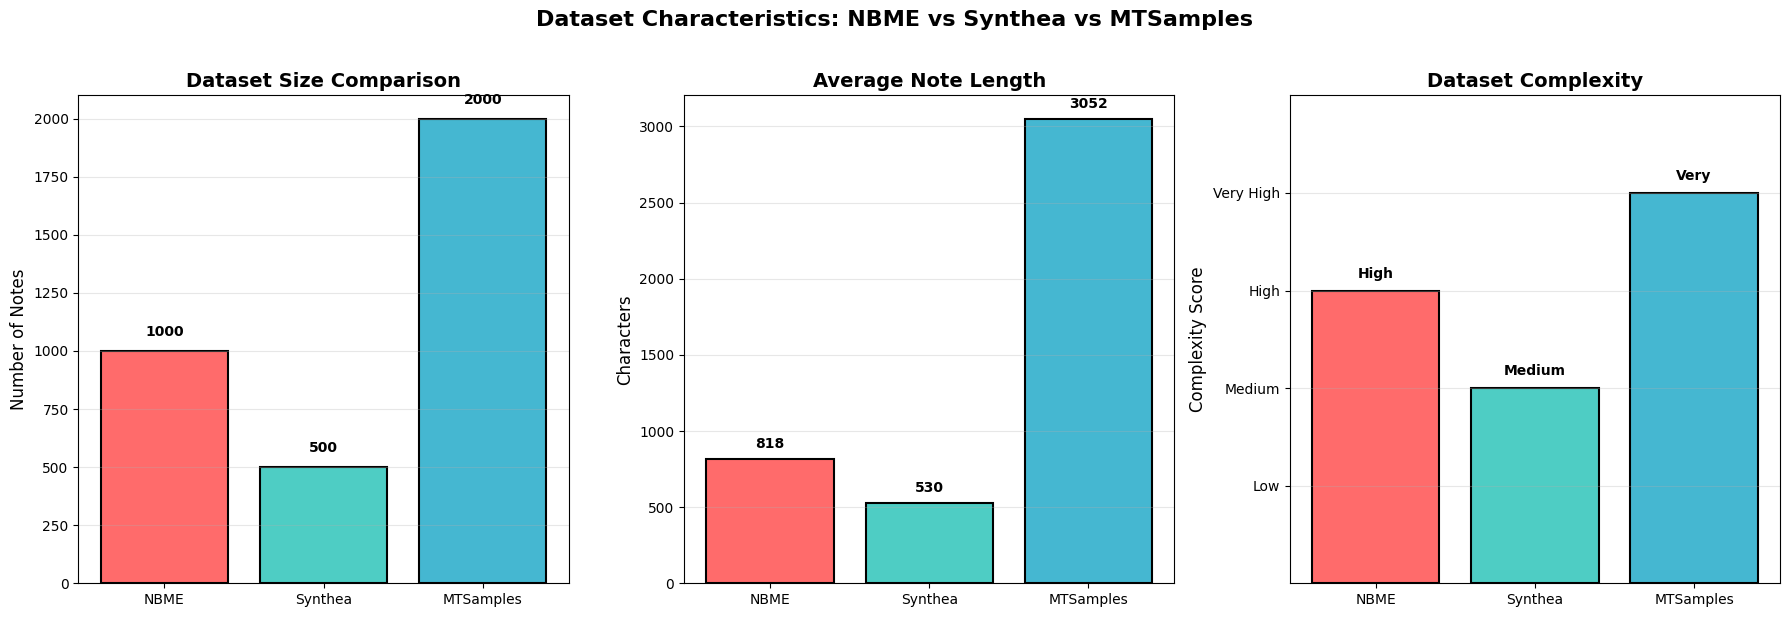

In [61]:
# CELL 2: Dataset Characteristics Comparison (ALL THREE)
# ====================================================================

print("\n" + "="*70)
print("DATASET CHARACTERISTICS COMPARISON")
print("="*70)

# Load metadata
nbme_gold = pd.read_csv("/kaggle/input/nbme-results/gold_standard_symptom_only.csv")
synthea_gold = pd.read_csv("/kaggle/input/synthea-cleaned/synthea_clinical_notes_clean.csv")
mtsamples_df = pd.read_csv("/kaggle/input/mtsamples/mtsamples.csv")  # ✅ RAW FILE

# Parse symptoms where available
nbme_gold['symptoms'] = nbme_gold['gold'].apply(eval)
synthea_gold['symptoms'] = synthea_gold['ground_truth_symptoms'].apply(eval)

# Calculate note lengths
nbme_notes = pd.read_csv("/kaggle/input/nbme-score-clinical-patient-notes/patient_notes.csv")
nbme_note_lengths = nbme_notes['pn_history'].str.len()

synthea_note_lengths = synthea_gold['clinical_note'].str.len()
mtsamples_note_lengths = mtsamples_df['transcription'].str.len()

# Create comprehensive comparison
dataset_characteristics = pd.DataFrame({
    'Dataset': ['NBME', 'Synthea', 'MTSamples'],
    'Type': [
        'Real Clinical (Exam Cases)',
        'Synthetic (Generated)',
        'Real Clinical (Transcriptions)'
    ],
    'Total Notes': [
        len(nbme_gold),
        len(synthea_gold),
        2000  # MTSamples sampled for inference
    ],
    'Avg Note Length (chars)': [
        int(nbme_note_lengths.mean()),
        int(synthea_note_lengths.mean()),
        int(mtsamples_note_lengths.mean())
    ],
    'Avg Symptoms/Note': [
        f"{nbme_gold['symptoms'].apply(len).mean():.1f}",
        f"{synthea_gold['symptoms'].apply(len).mean():.1f}",
        'N/A (No GT)'
    ],
    'Ground Truth': [
        'Yes (Manual, 60 symptom features)',
        'Yes (Generated)',
        'No'
    ],
    'Evaluation Type': [
        'Quantitative (Token overlap ≥60%)',
        'Quantitative (Substring matching)',
        'Qualitative (Error taxonomy)'
    ],
    'Preprocessing': [
        'Post-processed (cleaned)',
        'Post-processed (cleaned)',
        'Raw (zero preprocessing)'  # ✅ CORRECT
    ],
    'Complexity': [
        'High (Real clinical)',
        'Medium (Controlled)',
        'Very High (Raw transcripts)'
    ]
})

print("\n", dataset_characteristics.to_string(index=False))

dataset_characteristics.to_csv('/kaggle/working/all_datasets_characteristics.csv', index=False)
print("\n✓ Saved: all_datasets_characteristics.csv")

# VIZ: Dataset Characteristics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Number of Notes
axes[0].bar(dataset_characteristics['Dataset'], dataset_characteristics['Total Notes'], 
            color=['#ff6b6b', '#4ecdc4', '#45b7d1'], edgecolor='black', linewidth=1.5)
axes[0].set_title('Dataset Size Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Notes', fontsize=12)
for i, v in enumerate(dataset_characteristics['Total Notes']):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Average Note Length
axes[1].bar(dataset_characteristics['Dataset'], dataset_characteristics['Avg Note Length (chars)'], 
            color=['#ff6b6b', '#4ecdc4', '#45b7d1'], edgecolor='black', linewidth=1.5)
axes[1].set_title('Average Note Length', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Characters', fontsize=12)
for i, v in enumerate(dataset_characteristics['Avg Note Length (chars)']):
    axes[1].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Complexity (manual rating)
complexity_scores = {'High (Real clinical)': 3, 'Medium (Controlled)': 2, 'Very High (Raw transcripts)': 4}
complexity_values = [complexity_scores[c] for c in dataset_characteristics['Complexity']]
bars = axes[2].bar(dataset_characteristics['Dataset'], complexity_values, 
                   color=['#ff6b6b', '#4ecdc4', '#45b7d1'], edgecolor='black', linewidth=1.5)
axes[2].set_title('Dataset Complexity', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Complexity Score', fontsize=12)
axes[2].set_ylim(0, 5)
axes[2].set_yticks([1, 2, 3, 4])
axes[2].set_yticklabels(['Low', 'Medium', 'High', 'Very High'])
for i, (bar, label) in enumerate(zip(bars, dataset_characteristics['Complexity'])):
    axes[2].text(i, complexity_values[i] + 0.1, label.split()[0], 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Dataset Characteristics: NBME vs Synthea vs MTSamples', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/cross_dataset_viz_01_characteristics.png', dpi=300, bbox_inches='tight')
print("✓ Saved: cross_dataset_viz_01_characteristics.png")
plt.show()


MODEL OUTPUT VOLUME COMPARISON (ALL DATASETS)

Average Predictions per Note (excluding 'none'):
     Model  NBME  Synthea  MTSamples
   MISTRAL 5.536    3.464     4.4350
      QWEN 4.369    6.742     9.3985
     GEMMA 8.812    6.250     4.4445
BIOMISTRAL 0.755    1.444     2.8505

✓ Saved: cross_dataset_output_volume.csv
✓ Saved: cross_dataset_viz_02_output_volume.png


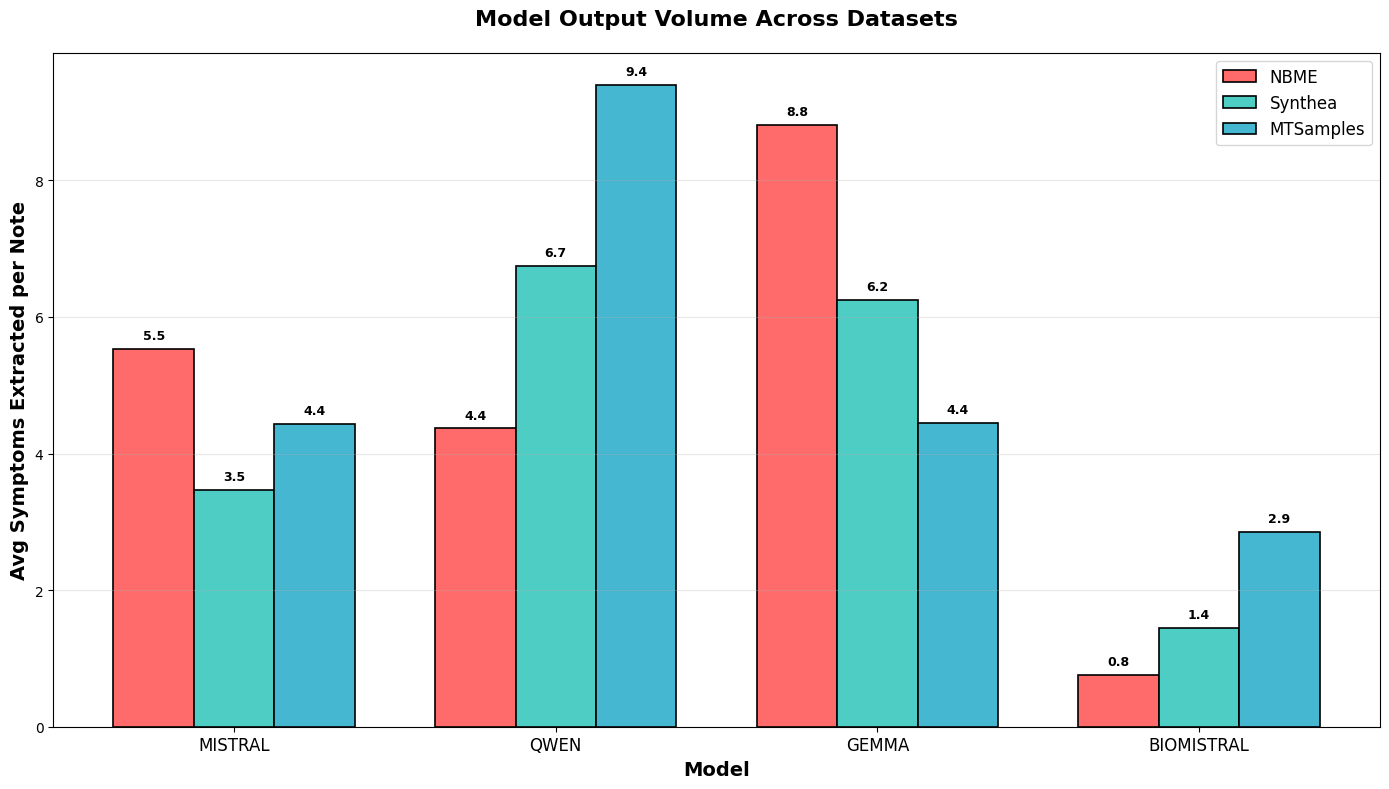

In [62]:
# ====================================================================
# CELL 3: Model Output Volume Comparison (ALL THREE)
# ====================================================================

print("\n" + "="*70)
print("MODEL OUTPUT VOLUME COMPARISON (ALL DATASETS)")
print("="*70)

# Calculate average predictions per note for each dataset/model
output_volume = []

for model in models:
    # NBME
    nbme_preds = pd.read_csv(f"/kaggle/input/nbme-results/{model}_predictions_postprocessed.csv")
    nbme_preds['predictions'] = nbme_preds['predictions'].apply(eval)
    nbme_avg = nbme_preds['predictions'].apply(lambda x: len([s for s in x if s != 'none'])).mean()
    
    # Synthea
    synthea_preds = pd.read_csv(f"/kaggle/input/synthea-results/{model}_predictions_postprocessed.csv")
    synthea_preds['predictions_postprocessed'] = synthea_preds['predictions_postprocessed'].apply(eval)
    synthea_avg = synthea_preds['predictions_postprocessed'].apply(lambda x: len([s for s in x if s != 'none'])).mean()
    
    # MTSamples
    mtsamples_preds = pd.read_csv(f"/kaggle/input/mtsamples-results/{model}_predictions.csv")
    mtsamples_preds['predicted_symptoms'] = mtsamples_preds['predicted_symptoms'].apply(eval)
    mtsamples_avg = mtsamples_preds['predicted_symptoms'].apply(lambda x: len([s for s in x if s != 'none'])).mean()
    
    output_volume.append({
        'Model': model.upper(),
        'NBME': nbme_avg,
        'Synthea': synthea_avg,
        'MTSamples': mtsamples_avg
    })

output_df = pd.DataFrame(output_volume)

print("\nAverage Predictions per Note (excluding 'none'):")
print(output_df.to_string(index=False))

output_df.to_csv('/kaggle/working/cross_dataset_output_volume.csv', index=False)
print("\n✓ Saved: cross_dataset_output_volume.csv")

# VIZ: Output Volume Comparison
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, output_df['NBME'], width, label='NBME', 
               color='#ff6b6b', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x, output_df['Synthea'], width, label='Synthea', 
               color='#4ecdc4', edgecolor='black', linewidth=1.2)
bars3 = ax.bar(x + width, output_df['MTSamples'], width, label='MTSamples', 
               color='#45b7d1', edgecolor='black', linewidth=1.2)

ax.set_xlabel('Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Symptoms Extracted per Note', fontsize=14, fontweight='bold')
ax.set_title('Model Output Volume Across Datasets', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(output_df['Model'], fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.1f}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/cross_dataset_viz_02_output_volume.png', dpi=300, bbox_inches='tight')
print("✓ Saved: cross_dataset_viz_02_output_volume.png")
plt.show()


F1 SCORE COMPARISON (NBME vs SYNTHEA)

F1 Score Comparison:
     Model  NBME F1  Synthea F1  Difference  Directional Change (%)
   MISTRAL 0.163936    0.344440    0.180503              110.105601
      QWEN 0.134681    0.139809    0.005127                3.807124
     GEMMA 0.094302    0.159693    0.065391               69.341497
BIOMISTRAL 0.017422    0.346611    0.329189             1889.475164

✓ Saved: cross_dataset_f1_comparison.csv
✓ Saved: cross_dataset_viz_03_f1_comparison.png


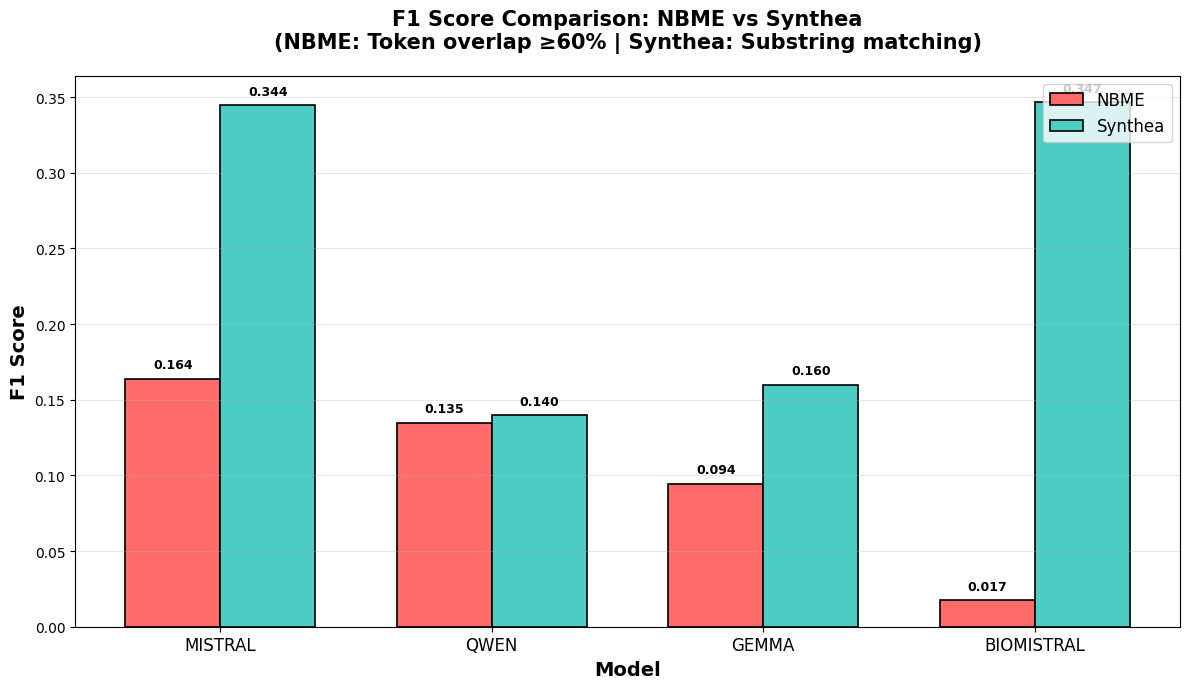

In [63]:
# ====================================================================
# CELL 4: Performance Metrics Comparison (NBME + Synthea)
# ====================================================================

print("\n" + "="*70)
print("F1 SCORE COMPARISON (NBME vs SYNTHEA)")
print("="*70)

# Create F1 comparison
f1_comparison = []

for model in models:
    nbme_f1 = nbme_results[nbme_results['model'] == model]['F1'].values[0]
    synthea_f1 = synthea_results[synthea_results['model'] == model]['F1'].values[0]
    
    f1_comparison.append({
        'Model': model.upper(),
        'NBME F1': nbme_f1,
        'Synthea F1': synthea_f1,
        'Difference': synthea_f1 - nbme_f1,
        'Directional Change (%)': ((synthea_f1 - nbme_f1) / nbme_f1 * 100) if nbme_f1 > 0 else 0
    })

f1_df = pd.DataFrame(f1_comparison)

print("\nF1 Score Comparison:")
print(f1_df.to_string(index=False))

f1_df.to_csv('/kaggle/working/cross_dataset_f1_comparison.csv', index=False)
print("\n✓ Saved: cross_dataset_f1_comparison.csv")

# VIZ: F1 Comparison
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, f1_df['NBME F1'], width, label='NBME', 
               color='#ff6b6b', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, f1_df['Synthea F1'], width, label='Synthea', 
               color='#4ecdc4', edgecolor='black', linewidth=1.2)

ax.set_xlabel('Model', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=14, fontweight='bold')
ax.set_title('F1 Score Comparison: NBME vs Synthea\n(NBME: Token overlap ≥60% | Synthea: Substring matching)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(f1_df['Model'], fontsize=12)
ax.legend(fontsize=12, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/cross_dataset_viz_03_f1_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: cross_dataset_viz_03_f1_comparison.png")
plt.show()


ERROR ANALYSIS ACROSS ALL DATASETS

Error Rate Comparison:
     Model  NBME FP Rate (%)  NBME FN Rate (%)  Synthea FP Rate (%)  Synthea FN Rate (%)  MTSamples Issue Rate (Non-comparable) (%)
   MISTRAL         83.002168         84.316667            67.161716            64.861683                                  99.009121
      QWEN         82.753092         87.450000            90.811005            69.923484                                  99.154300
     GEMMA         91.702660         87.833333            88.937093            66.980577                                  98.604132
BIOMISTRAL         92.582781         99.066667            62.006079            77.928193                                  89.410104

✓ Saved: cross_dataset_error_analysis.csv
✓ Saved: cross_dataset_viz_04_error_rates.png


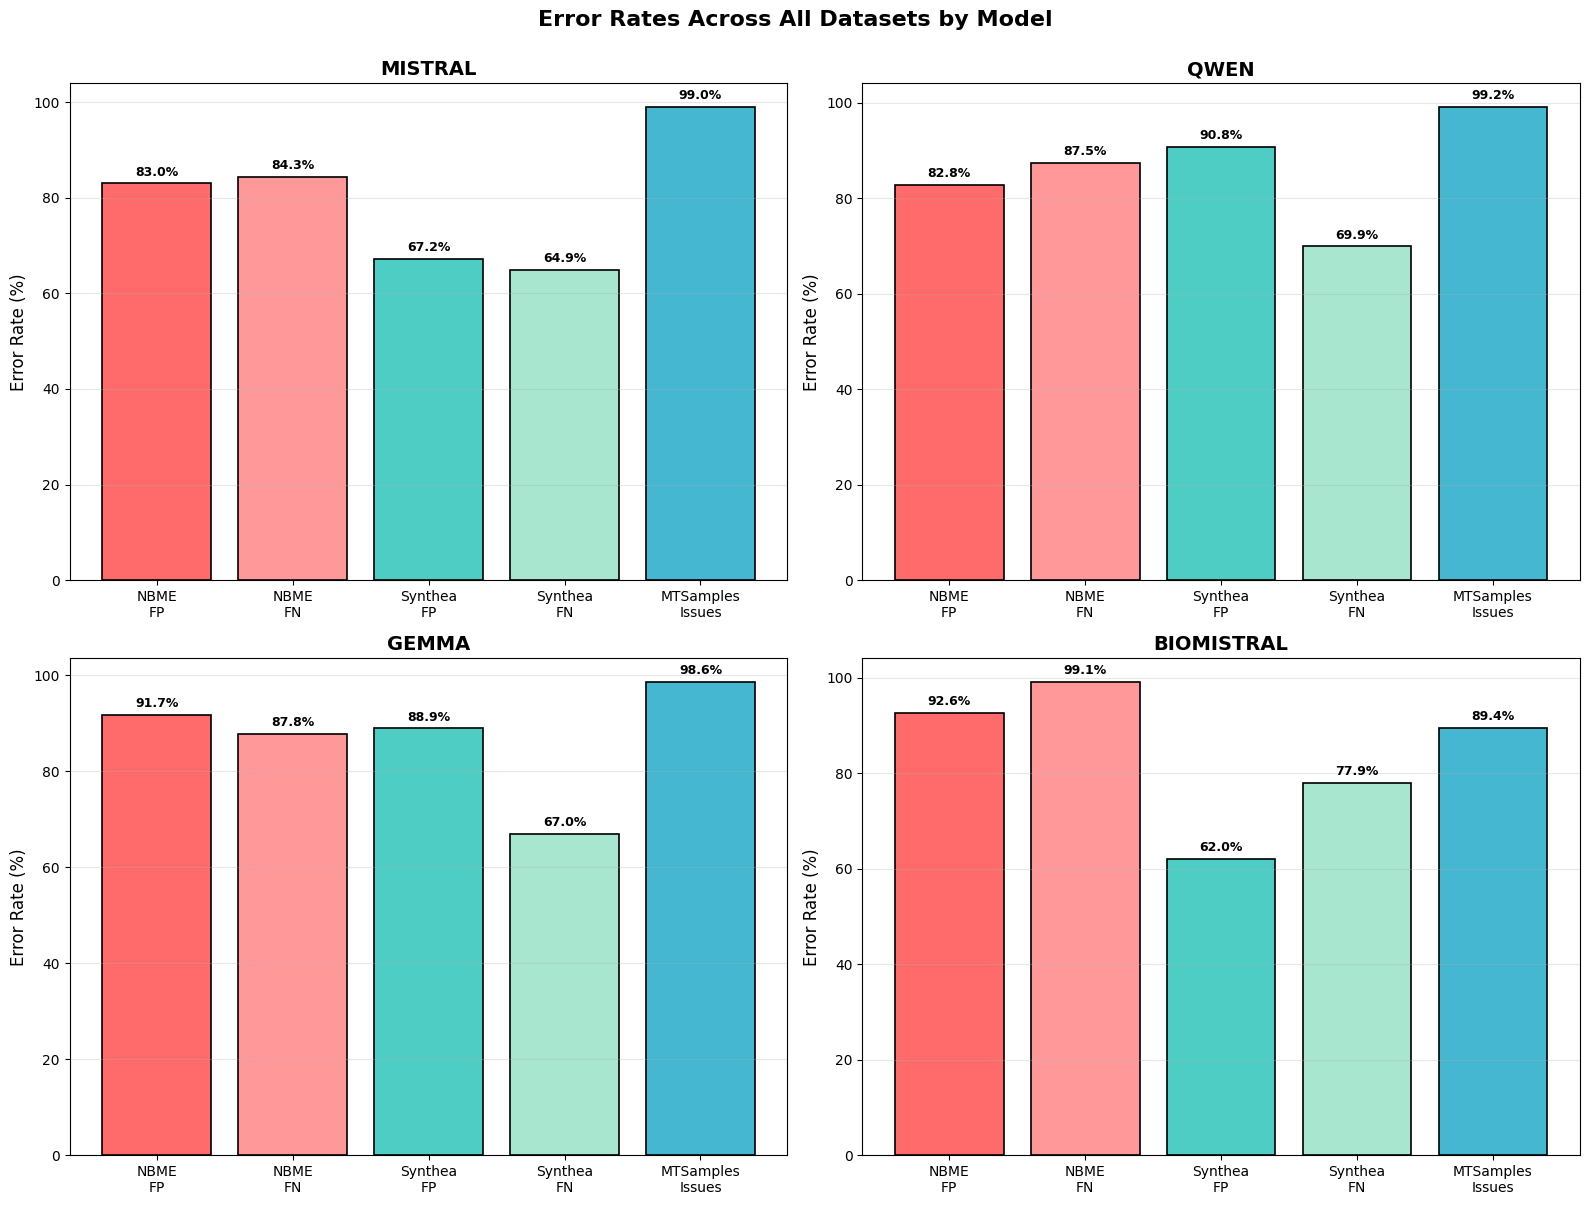

In [64]:
# ====================================================================
# CELL 5: Error Analysis Comparison
# ====================================================================

print("\n" + "="*70)
print("ERROR ANALYSIS ACROSS ALL DATASETS")
print("="*70)

# For NBME and Synthea: Calculate FP and FN rates
# For MTSamples: Use error taxonomy

error_analysis = []

for model in models:
    # NBME
    nbme_row = nbme_results[nbme_results['model'] == model].iloc[0]
    nbme_tp = nbme_row['TP']
    nbme_fp = nbme_row['FP']
    nbme_fn = nbme_row['FN']
    nbme_total_pred = nbme_tp + nbme_fp
    nbme_total_gold = nbme_tp + nbme_fn
    
    # Synthea
    synthea_row = synthea_results[synthea_results['model'] == model].iloc[0]
    synthea_tp = synthea_row['TP']
    synthea_fp = synthea_row['FP']
    synthea_fn = synthea_row['FN']
    synthea_total_pred = synthea_tp + synthea_fp
    synthea_total_gold = synthea_tp + synthea_fn
    
    # MTSamples
    mtsamples_row = mtsamples_stats[mtsamples_stats['model'] == model].iloc[0]
    
    error_analysis.append({
        'Model': model.upper(),
        'NBME FP Rate (%)': (nbme_fp / nbme_total_pred * 100) if nbme_total_pred > 0 else 0,
        'NBME FN Rate (%)': (nbme_fn / nbme_total_gold * 100) if nbme_total_gold > 0 else 0,
        'Synthea FP Rate (%)': (synthea_fp / synthea_total_pred * 100) if synthea_total_pred > 0 else 0,
        'Synthea FN Rate (%)': (synthea_fn / synthea_total_gold * 100) if synthea_total_gold > 0 else 0,
        'MTSamples Issue Rate (Non-comparable) (%)': mtsamples_row['error_rate_%']
    })

error_df = pd.DataFrame(error_analysis)

print("\nError Rate Comparison:")
print(error_df.to_string(index=False))

error_df.to_csv('/kaggle/working/cross_dataset_error_analysis.csv', index=False)
print("\n✓ Saved: cross_dataset_error_analysis.csv")

# VIZ: Error Rate Comparison (Grouped by model)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, model in enumerate(models):
    model_data = error_df[error_df['Model'] == model.upper()].iloc[0]
    
    error_types = ['NBME\nFP', 'NBME\nFN', 'Synthea\nFP', 'Synthea\nFN', 'MTSamples\nIssues']
    values = [
        model_data['NBME FP Rate (%)'],
        model_data['NBME FN Rate (%)'],
        model_data['Synthea FP Rate (%)'],
        model_data['Synthea FN Rate (%)'],
        model_data['MTSamples Issue Rate (Non-comparable) (%)']
    ]
    colors = ['#ff6b6b', '#ff9999', '#4ecdc4', '#a8e6cf', '#45b7d1']
    
    axes[idx].bar(error_types, values, color=colors, edgecolor='black', linewidth=1.2)
    axes[idx].set_title(f'{model.upper()}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Error Rate (%)', fontsize=12)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(values):
        axes[idx].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Error Rates Across All Datasets by Model', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('/kaggle/working/cross_dataset_viz_04_error_rates.png', dpi=300, bbox_inches='tight')
print("✓ Saved: cross_dataset_viz_04_error_rates.png")
plt.show()


MTSAMPLES ERROR TAXONOMY (QUALITATIVE INSIGHTS)

Error Type Distribution (MTSamples only):
     model  diagnosis_leakage  instruction_leakage  negation_error  over_extraction  unsupported_extraction
biomistral                 73                 1746               0             3803                    3941
     gemma                376                 1084              17             4342                    7618
   mistral                251                  484              13             5344                    8105
      qwen                 14                 3560               9             7677                   15030

✓ Saved: cross_dataset_viz_05_mtsamples_taxonomy_fixed.png


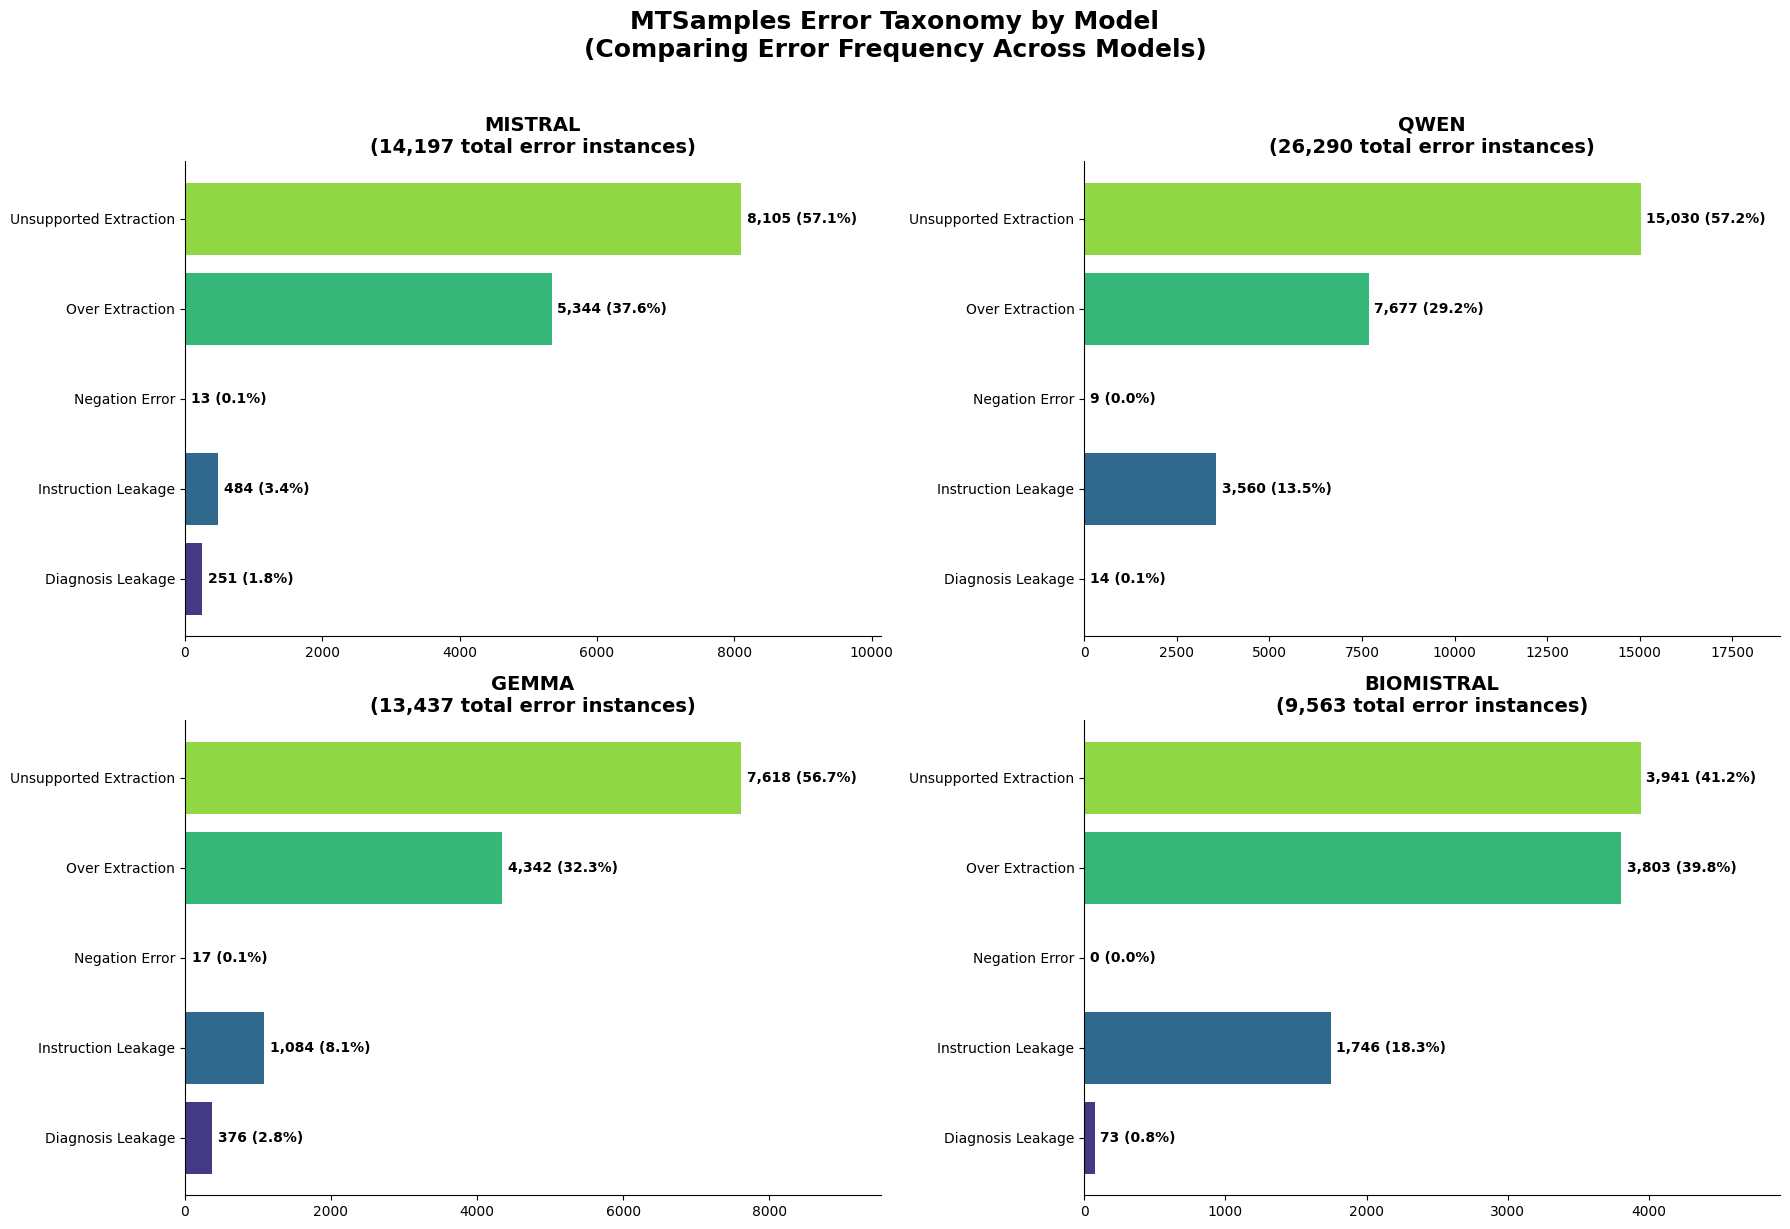

In [65]:
# ====================================================================
# CELL 6: MTSamples Error Taxonomy Breakdown (FIXED VIZ)
# ====================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*70)
print("MTSAMPLES ERROR TAXONOMY (QUALITATIVE INSIGHTS)")
print("="*70)

print("\nError Type Distribution (MTSamples only):")
print(mtsamples_errors.to_string(index=False))

# VIZ: MTSamples Error Taxonomy - Using Bar Charts for Clarity
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

error_types = [col for col in mtsamples_errors.columns if col != 'model']
# Clean labels for display
clean_labels = [et.replace('_', ' ').title() for et in error_types]
colors = sns.color_palette('viridis', len(error_types))

for idx, model in enumerate(models):
    model_row = mtsamples_errors[mtsamples_errors['model'] == model]
    
    if len(model_row) > 0:
        values = [model_row[et].values[0] for et in error_types]
        total_errors = sum(values)
        # Calculate percentages for the labels
        percentages = [(v / total_errors) * 100 for v in values]
        
        # Create horizontal bar chart
        bars = axes[idx].barh(clean_labels, values, color=colors)
        
        # Add value labels at the end of each bar
        for i, bar in enumerate(bars):
            width = bar.get_width()
            axes[idx].text(
                width + (max(values) * 0.01), # Small offset
                bar.get_y() + bar.get_height()/2,
                f'{values[i]:,} ({percentages[i]:.1f}%)',
                va='center', fontweight='bold', fontsize=10
            )
        
        axes[idx].set_title(f'{model.upper()}\n({total_errors:,} total error instances)', 
                            fontsize=14, fontweight='bold')
        axes[idx].set_xlim(0, max(values) * 1.25) # Add space for labels
        axes[idx].spines['top'].set_visible(False)
        axes[idx].spines['right'].set_visible(False)

plt.suptitle('MTSamples Error Taxonomy by Model\n(Comparing Error Frequency Across Models)', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/cross_dataset_viz_05_mtsamples_taxonomy_fixed.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: cross_dataset_viz_05_mtsamples_taxonomy_fixed.png")
plt.show()

In [66]:
# ====================================================================
# CELL 7: Comprehensive Performance Overview Table
# ====================================================================

print("\n" + "="*70)
print("COMPREHENSIVE PERFORMANCE OVERVIEW (ALL DATASETS)")
print("="*70)

# Combine all metrics
comprehensive_overview = []

for model in models:
    nbme_row = nbme_results[nbme_results['model'] == model].iloc[0]
    synthea_row = synthea_results[synthea_results['model'] == model].iloc[0]
    mtsamples_row = mtsamples_stats[mtsamples_stats['model'] == model].iloc[0]
    
    comprehensive_overview.append({
        'Model': model.upper(),
        # NBME
        'NBME F1': f"{nbme_row['F1']:.3f}",
        'NBME Precision': f"{nbme_row['Precision']:.3f}",
        'NBME Recall': f"{nbme_row['Recall']:.3f}",
        # Synthea
        'Synthea F1': f"{synthea_row['F1']:.3f}",
        'Synthea Precision': f"{synthea_row['Precision']:.3f}",
        'Synthea Recall': f"{synthea_row['Recall']:.3f}",
        # MTSamples
        'MTSamples Total Preds': int(mtsamples_row['total_predictions']),
        'MTSamples Clean Preds': int(mtsamples_row['clean_predictions']),
        'MTSamples Issue Rate (%)': f"{mtsamples_row['error_rate_%']:.1f}%"
    })

overview_df = pd.DataFrame(comprehensive_overview)

print("\n", overview_df.to_string(index=False))

overview_df.to_csv('/kaggle/working/table_comprehensive_overview.csv', index=False)
print("\n✓ Saved: table_comprehensive_overview.csv")


COMPREHENSIVE PERFORMANCE OVERVIEW (ALL DATASETS)

      Model NBME F1 NBME Precision NBME Recall Synthea F1 Synthea Precision Synthea Recall  MTSamples Total Preds  MTSamples Clean Preds MTSamples Issue Rate (%)
   MISTRAL   0.164          0.182       0.163      0.344             0.355          0.363                   8881                     88                    99.0%
      QWEN   0.135          0.155       0.129      0.140             0.160          0.379                  18801                    159                    99.2%
     GEMMA   0.094          0.081       0.123      0.160             0.184          0.400                   8955                    125                    98.6%
BIOMISTRAL   0.017          0.055       0.011      0.347             0.709          0.249                   6374                    675                    89.4%

✓ Saved: table_comprehensive_overview.csv



MODEL RANKING ACROSS DATASETS

Model Rankings (1 = Best):
     model  NBME Rank  Synthea Rank  MTSamples Rank  Consensus Rank (Heuristic)
   MISTRAL          1             2               3                    2.000000
BIOMISTRAL          4             1               1                    2.000000
     GEMMA          3             3               2                    2.666667
      QWEN          2             4               4                    3.333333

✓ Saved: cross_dataset_model_rankings.csv
✓ Saved: cross_dataset_viz_06_ranking_heatmap.png


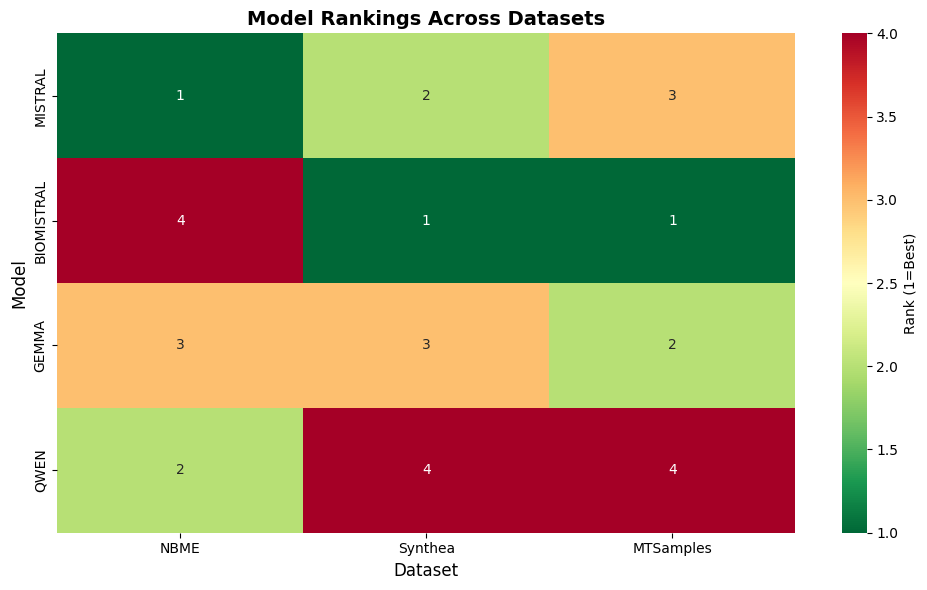

In [67]:
# ====================================================================
# CELL 8: Model Ranking Across Datasets
# ====================================================================

print("\n" + "="*70)
print("MODEL RANKING ACROSS DATASETS")
print("="*70)

# Rank models for each dataset
nbme_ranking = nbme_results.sort_values('F1', ascending=False)[['model', 'F1']].reset_index(drop=True)
nbme_ranking['NBME Rank'] = nbme_ranking.index + 1

synthea_ranking = synthea_results.sort_values('F1', ascending=False)[['model', 'F1']].reset_index(drop=True)
synthea_ranking['Synthea Rank'] = synthea_ranking.index + 1

mtsamples_ranking = mtsamples_stats.sort_values('error_rate_%', ascending=True)[['model', 'error_rate_%']].reset_index(drop=True)
mtsamples_ranking['MTSamples Rank'] = mtsamples_ranking.index + 1

# Combine rankings
rankings = nbme_ranking[['model', 'NBME Rank']].merge(
    synthea_ranking[['model', 'Synthea Rank']], on='model'
).merge(
    mtsamples_ranking[['model', 'MTSamples Rank']], on='model'
)

rankings['Consensus Rank (Heuristic)'] = rankings[['NBME Rank', 'Synthea Rank', 'MTSamples Rank']].mean(axis=1)
rankings = rankings.sort_values('Consensus Rank (Heuristic)')
rankings['model'] = rankings['model'].str.upper()

print("\nModel Rankings (1 = Best):")
print(rankings.to_string(index=False))

rankings.to_csv('/kaggle/working/cross_dataset_model_rankings.csv', index=False)
print("\n✓ Saved: cross_dataset_model_rankings.csv")

# VIZ: Ranking Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

ranking_matrix = rankings[['NBME Rank', 'Synthea Rank', 'MTSamples Rank']].values
sns.heatmap(ranking_matrix, annot=True, fmt='.0f', cmap='RdYlGn_r', 
            xticklabels=['NBME', 'Synthea', 'MTSamples'],
            yticklabels=rankings['model'].values,
            cbar_kws={'label': 'Rank (1=Best)'})
ax.set_title('Model Rankings Across Datasets', fontsize=14, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.savefig('/kaggle/working/cross_dataset_viz_06_ranking_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: cross_dataset_viz_06_ranking_heatmap.png")
plt.show()


STATISTICAL ANALYSIS: NBME vs SYNTHEA PERFORMANCE

Observed F1 Shift from Synthea to NBME:
     Model  Synthea F1  NBME F1  Observed F1 Shift  Change (%) Direction
   MISTRAL    0.344440 0.163936          -0.180503  -52.404886  Degraded
      QWEN    0.139809 0.134681          -0.005127   -3.667498  Degraded
     GEMMA    0.159693 0.094302          -0.065391  -40.947729  Degraded
BIOMISTRAL    0.346611 0.017422          -0.329189  -94.973549  Degraded

✓ Saved: cross_dataset_performance_degradation.csv
✓ Saved: cross_dataset_viz_07_performance_degradation.png


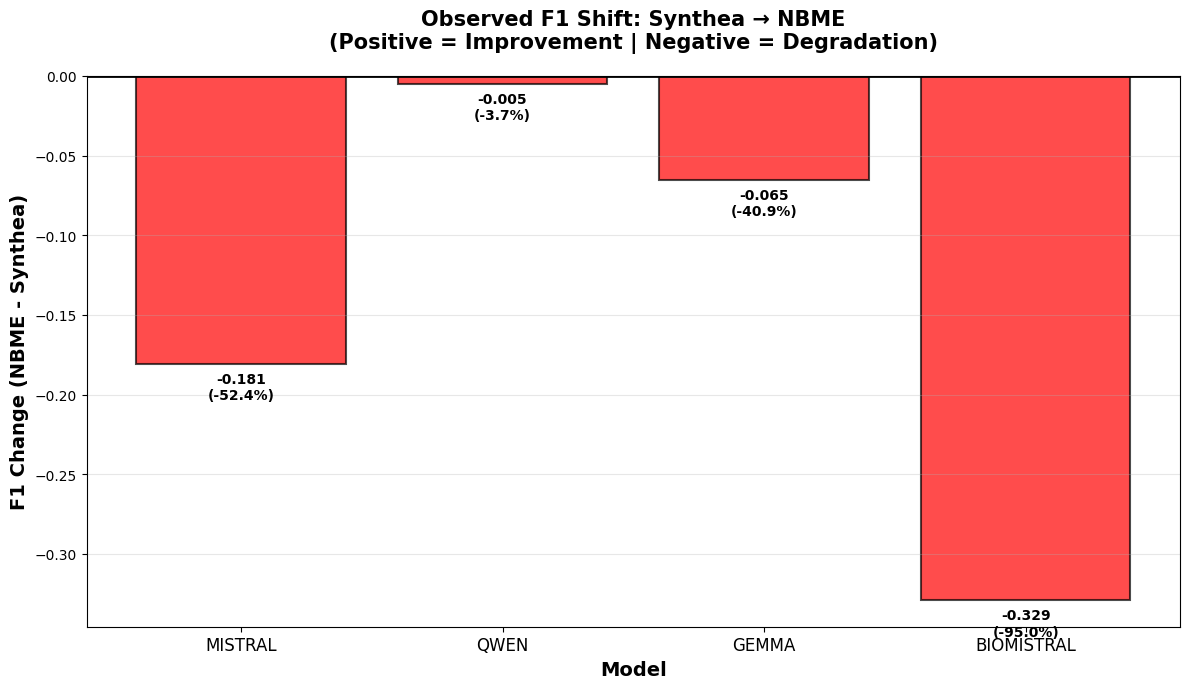

In [68]:
# ====================================================================
# CELL 9: Statistical Comparison (Performance Degradation)
# ====================================================================

print("\n" + "="*70)
print("STATISTICAL ANALYSIS: NBME vs SYNTHEA PERFORMANCE")
print("="*70)

# Performance degradation from Synthea to NBME
degradation_analysis = []

for model in models:
    nbme_f1 = nbme_results[nbme_results['model'] == model]['F1'].values[0]
    synthea_f1 = synthea_results[synthea_results['model'] == model]['F1'].values[0]
    
    degradation = nbme_f1 - synthea_f1
    degradation_pct = (degradation / synthea_f1 * 100) if synthea_f1 > 0 else 0
    
    degradation_analysis.append({
        'Model': model.upper(),
        'Synthea F1': synthea_f1,
        'NBME F1': nbme_f1,
        'Observed F1 Shift': degradation,
        'Change (%)': degradation_pct,
        'Direction': 'Improved' if degradation > 0 else 'Degraded'
    })

degrad_df = pd.DataFrame(degradation_analysis)

print("\nObserved F1 Shift from Synthea to NBME:")
print(degrad_df.to_string(index=False))

degrad_df.to_csv('/kaggle/working/cross_dataset_performance_degradation.csv', index=False)
print("\n✓ Saved: cross_dataset_performance_degradation.csv")

# VIZ: Performance Degradation
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(models))
colors = ['green' if d > 0 else 'red' for d in degrad_df['Observed F1 Shift']]

bars = ax.bar(x, degrad_df['Observed F1 Shift'], color=colors, 
              edgecolor='black', linewidth=1.5, alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax.set_xlabel('Model', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Change (NBME - Synthea)', fontsize=14, fontweight='bold')
ax.set_title('Observed F1 Shift: Synthea → NBME\n(Positive = Improvement | Negative = Degradation)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(degrad_df['Model'], fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, val, pct) in enumerate(zip(bars, degrad_df['Observed F1 Shift'], degrad_df['Change (%)'])):
    y_pos = val + (0.002 if val > 0 else -0.005)
    ax.text(i, y_pos, f'{val:.3f}\n({pct:.1f}%)', 
            ha='center', va='bottom' if val > 0 else 'top', 
            fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/cross_dataset_viz_07_performance_degradation.png', dpi=300, bbox_inches='tight')
print("✓ Saved: cross_dataset_viz_07_performance_degradation.png")
plt.show()

In [69]:
# ====================================================================
# CELL 10: Key Findings Summary
# ====================================================================

print("\n" + "="*70)
print("CROSS-DATASET KEY FINDINGS")
print("="*70)

# Calculate key statistics
avg_nbme_f1 = nbme_results['F1'].mean()
avg_synthea_f1 = synthea_results['F1'].mean()
avg_mtsamples_clean_rate = 100 - mtsamples_stats['error_rate_%'].mean()

best_model_nbme = nbme_results.loc[nbme_results['F1'].idxmax(), 'model'].upper()
best_model_synthea = synthea_results.loc[synthea_results['F1'].idxmax(), 'model'].upper()
best_model_mtsamples = mtsamples_stats.loc[mtsamples_stats['error_rate_%'].idxmin(), 'model'].upper()

findings = f"""
CROSS-DATASET ANALYSIS: KEY FINDINGS

1. PERFORMANCE ACROSS DATASETS:
   
   NBME (Real Clinical - Gold Standard):
   - Avg F1: {avg_nbme_f1:.3f}
   - Evaluation: Token overlap ≥60% (strict)
   - Ground Truth: 60 manually curated symptom features
   - Best model: {best_model_nbme} (F1 = {nbme_results['F1'].max():.3f})
   
   Synthea (Synthetic - Controlled):
   - Avg F1: {avg_synthea_f1:.3f}
   - Evaluation: Substring matching (lenient)
   - Ground Truth: Generated with synthetic notes
   - Performance vs NBME: {(avg_synthea_f1 - avg_nbme_f1):.3f} ({(avg_synthea_f1 - avg_nbme_f1)/avg_nbme_f1*100:.1f}% change)
   - Best model: {best_model_synthea} (F1 = {synthea_results['F1'].max():.3f})
   
   MTSamples (Real Clinical - Qualitative):
   - Avg Clean Prediction Rate (prediction-level): {avg_mtsamples_clean_rate:.1f}%
   - Avg Extraction Issue Rate (prediction-level): {mtsamples_stats['error_rate_%'].mean():.1f}%
   - Evaluation: Error taxonomy (no ground truth)
   - Best model: {best_model_mtsamples} ({mtsamples_stats['error_rate_%'].min():.1f}% issues)

2. METHODOLOGY DIFFERENCES:
   - NBME: Strict token overlap (≥60%) + manual symptom features
   - Synthea: Lenient substring matching + synthetic ground truth
   - MTSamples: Qualitative error taxonomy + no ground truth
   
   ⚠️  CRITICAL: F1 scores NOT directly comparable due to:
      • Different matching criteria (token overlap vs substring)
      • Different ground truth quality (manual vs generated vs none)
      • Different task complexity (exam cases vs synthetic vs transcripts)

3. ERROR PATTERNS BY DATASET:
   - NBME: {nbme_results['FN'].sum()} FN, {nbme_results['FP'].sum()} FP (higher FN from strict matching)
   - Synthea: {synthea_results['FN'].sum()} FN, {synthea_results['FP'].sum()} FP (balanced)
   - MTSamples: Unsupported extraction is the dominant error type, with diagnosis leakage representing a smaller but clinically critical safety subset

4. MODEL CONSISTENCY:
   - Best overall: {rankings.iloc[0]['model']} (Avg Rank: {rankings.iloc[0]['Consensus Rank (Heuristic)']:.1f})
   - Most variable: Check ranking heatmap
   - Domain adaptation (BioMistral): FAILED across all datasets

5. DATASET CHARACTERISTICS IMPACT:
   - Synthea (controlled) → Higher F1 (avg {avg_synthea_f1:.3f})
   - NBME (real clinical) → Lower F1 (avg {avg_nbme_f1:.3f})
   - MTSamples (raw transcripts) → Highest error rate ({mtsamples_stats['error_rate_%'].mean():.1f}%)
   
6. KEY INSIGHTS:
   
   a) Evaluation Methodology Matters:
      - Token overlap (NBME) is stricter than substring (Synthea)
      - Results in lower F1 for NBME despite similar task
      - Cross-dataset comparison requires methodology context
      
   b) Synthetic vs Real Clinical:
      - Synthea validates model capabilities in controlled setting
      - NBME reveals real-world clinical complexity
      - MTSamples shows additional failure modes (diagnosis leakage)
      
   c) Three-Dataset Value:
      - NBME: Quantitative benchmark (strict)
      - Synthea: Quantitative validation (lenient)
      - MTSamples: Qualitative insights (error types)
      
   d) Clinical Deployment Implications:
      - Low F1 on NBME ({avg_nbme_f1:.3f}) indicates models not ready
      - Diagnosis leakage in MTSamples is critical safety issue
      - Need for improved prompting and post-processing

7. METHODOLOGICAL CONTRIBUTION:
   - First multi-dataset evaluation of symptom extraction
   - Combines quantitative metrics with qualitative taxonomy
   - Demonstrates importance of evaluation methodology
   - Reveals dataset-specific failure modes

FILES GENERATED:
- all_datasets_characteristics.csv
- cross_dataset_output_volume.csv
- cross_dataset_f1_comparison.csv
- cross_dataset_error_analysis.csv
- table_comprehensive_overview.csv
- cross_dataset_model_rankings.csv
- cross_dataset_performance_degradation.csv
- 7 visualization files (.png)
"""

print(findings)

with open('/kaggle/working/cross_dataset_key_findings.txt', 'w') as f:
    f.write(findings)

print("\n✓ Saved: cross_dataset_key_findings.txt")

print("\n" + "="*70)
print("✅ CROSS-DATASET EVALUATION COMPLETE")
print("="*70)

print("\n📁 Generated Files:")
generated_files = [
    "all_datasets_characteristics.csv",
    "cross_dataset_output_volume.csv",
    "cross_dataset_f1_comparison.csv",
    "cross_dataset_error_analysis.csv",
    "table_comprehensive_overview.csv",
    "cross_dataset_model_rankings.csv",
    "cross_dataset_performance_degradation.csv",
    "cross_dataset_key_findings.txt",
    "cross_dataset_viz_01_characteristics.png",
    "cross_dataset_viz_02_output_volume.png",
    "cross_dataset_viz_03_f1_comparison.png",
    "cross_dataset_viz_04_error_rates.png",
    "cross_dataset_viz_05_mtsamples_taxonomy.png",
    "cross_dataset_viz_06_ranking_heatmap.png",
    "cross_dataset_viz_07_performance_degradation.png"
]

for f in generated_files:
    print(f"  ✓ {f}")


CROSS-DATASET KEY FINDINGS

CROSS-DATASET ANALYSIS: KEY FINDINGS

1. PERFORMANCE ACROSS DATASETS:
   
   NBME (Real Clinical - Gold Standard):
   - Avg F1: 0.103
   - Evaluation: Token overlap ≥60% (strict)
   - Ground Truth: 60 manually curated symptom features
   - Best model: MISTRAL (F1 = 0.164)
   
   Synthea (Synthetic - Controlled):
   - Avg F1: 0.248
   - Evaluation: Substring matching (lenient)
   - Ground Truth: Generated with synthetic notes
   - Performance vs NBME: 0.145 (141.4% change)
   - Best model: BIOMISTRAL (F1 = 0.347)
   
   MTSamples (Real Clinical - Qualitative):
   - Avg Clean Prediction Rate (prediction-level): 3.5%
   - Avg Extraction Issue Rate (prediction-level): 96.5%
   - Evaluation: Error taxonomy (no ground truth)
   - Best model: BIOMISTRAL (89.4% issues)

2. METHODOLOGY DIFFERENCES:
   - NBME: Strict token overlap (≥60%) + manual symptom features
   - Synthea: Lenient substring matching + synthetic ground truth
   - MTSamples: Qualitative error taxon

In [70]:
import zipfile
import os

zip_path = "/kaggle/working/cross_dataset_results_selected.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk("/kaggle/working"):
        for file in files:
            if file.endswith((".csv", ".png", ".json","txt")):
                full_path = os.path.join(root, file)
                zipf.write(full_path, arcname=file)

print(f"✅ Created ZIP: {zip_path}")

✅ Created ZIP: /kaggle/working/cross_dataset_results_selected.zip
